# PLATO Light Curve Simulation and Transit Detection Pipeline

This notebook demonstrates the generation and analysis of simulated PLATO-like stellar light curves using PSLS.

The dataset contains four classes:

- Class 0 → No planet, no activity
- Class 1 → No planet, activity only
- Class 2 → Planet + mild activity
- Class 3 → Planet + strong activity

The goal is to prepare a machine learning-ready dataset for exoplanet transit detection under stellar activity and correlated noise.

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
metadata = pd.read_csv("/home/israt/Downloads/psls/metadata_from_dat.csv")

metadata.head()

,filename,class,has_planet,has_activity,flux_mean,flux_std,amplitude,n_points,duration
0,output_class0/0000000045.dat,0,0,0,-3.332087,550.889575,5105.803782,899517,266.999421
1,output_class0/0000000235.dat,0,0,0,-3.311333,584.211388,5059.055203,899517,266.999421
2,output_class0/0000000011.dat,0,0,0,18.225642,957.214158,8574.299067,899517,266.999421
3,output_class0/0000000190.dat,0,0,0,4.243078,252.657237,2317.722731,899517,266.999421
4,output_class0/0000000234.dat,0,0,0,-4.264589,223.233544,2076.085942,899517,266.999421


In [22]:
print("Total samples:", len(metadata))




print("\nClass distribution:")
print(metadata["class"].value_counts())




Total samples: 1000

Class distribution:
class
0    250
1    250
2    250
3    250
Name: count, dtype: int64


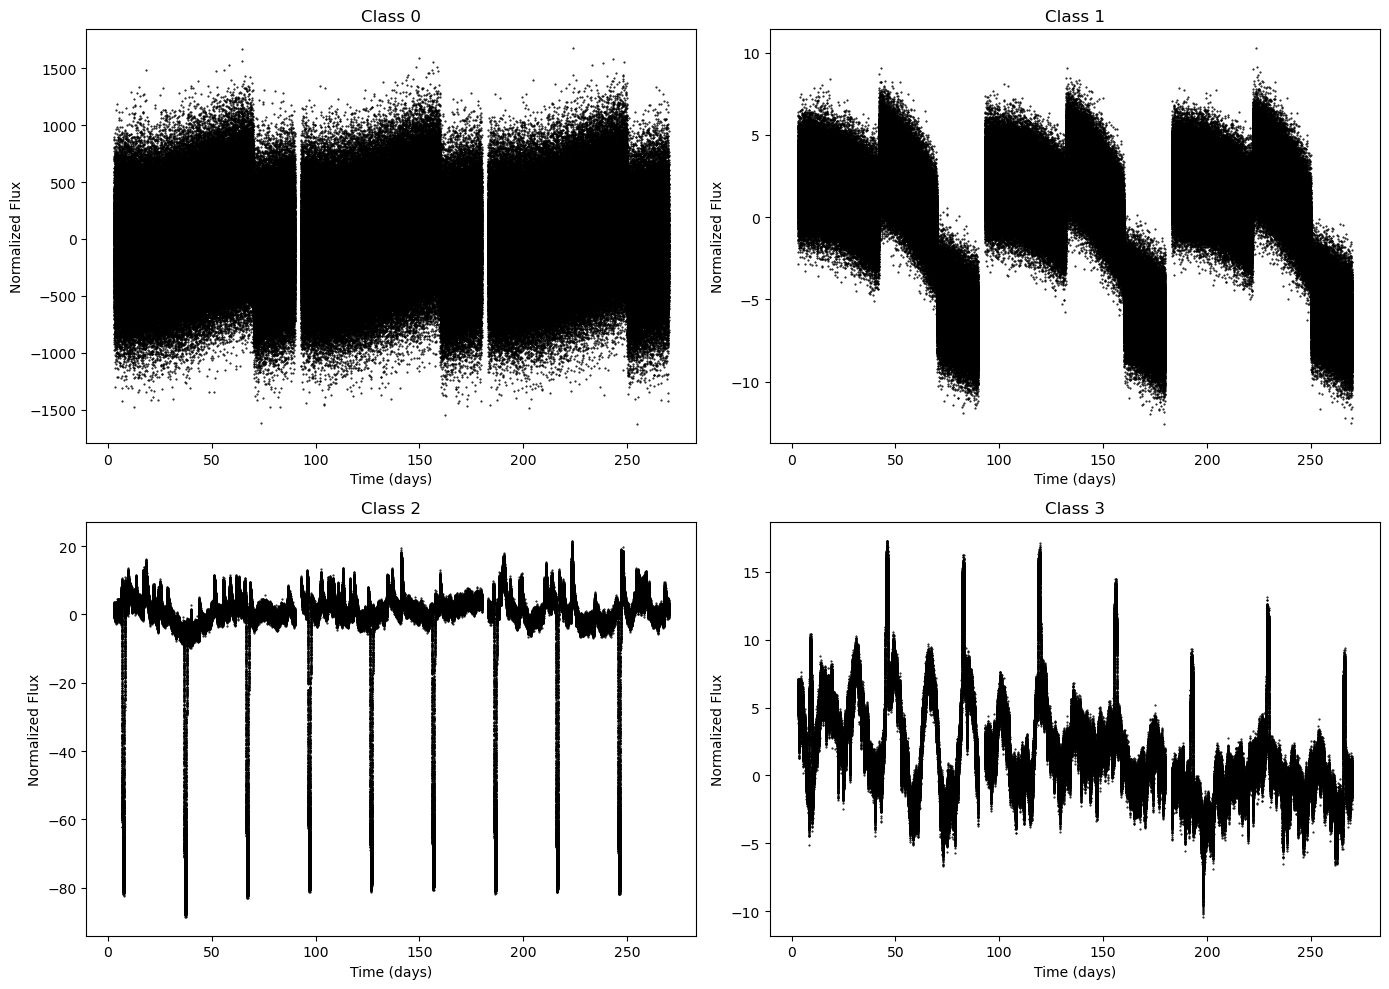

In [23]:
import os

classes = [0,1,2,3]

plt.figure(figsize=(14,10))

for i, cls in enumerate(classes):

    row = metadata[metadata["class"] == cls].iloc[0]

    file = row["filename"]

    full_path = os.path.join("/home/israt/Downloads/psls", file)

    data = np.loadtxt(full_path)

    time = data[:,0] / 86400.0
    flux = data[:,1]

    flux = flux / np.median(flux)

    plt.subplot(2,2,i+1)

    plt.plot(time, flux, 'k.', markersize=1)

    plt.title(f"Class {cls}")

    plt.xlabel("Time (days)")
    plt.ylabel("Normalized Flux")

plt.tight_layout()
plt.show()

## Interpretation of the classes

### Class 0
No planet and no stellar activity.

### Class 1
No planet but strong stellar activity.

### Class 2
Planetary transit with mild stellar activity.

### Class 3
Planetary transit with strong stellar activity.

These classes are useful for evaluating how stellar variability affects transit detection performance.

In [24]:
metadata.describe()

,class,has_planet,has_activity,flux_mean,flux_std,amplitude,n_points,duration
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,1.500000,0.50000,0.750000,-1169.718804,5167.118378,35959.353338,899517.655000,2.669994e+02
std,1.118593,0.50025,0.433229,1574.099790,6268.178776,41340.495036,15.404651,2.843593e-12
min,0.000000,0.00000,0.000000,-5844.135209,171.528728,1630.905261,899469.000000,2.669994e+02
25%,0.750000,0.00000,0.750000,-2242.973087,429.960444,3734.563097,899517.000000,2.669994e+02
50%,1.500000,0.50000,1.000000,-15.236443,1491.215723,13793.040138,899517.000000,2.669994e+02
75%,2.250000,1.00000,1.000000,2.059641,8646.172312,61312.583549,899517.000000,2.669994e+02
max,3.000000,1.00000,1.000000,225.335154,22942.741225,151587.767060,899565.000000,2.669994e+02


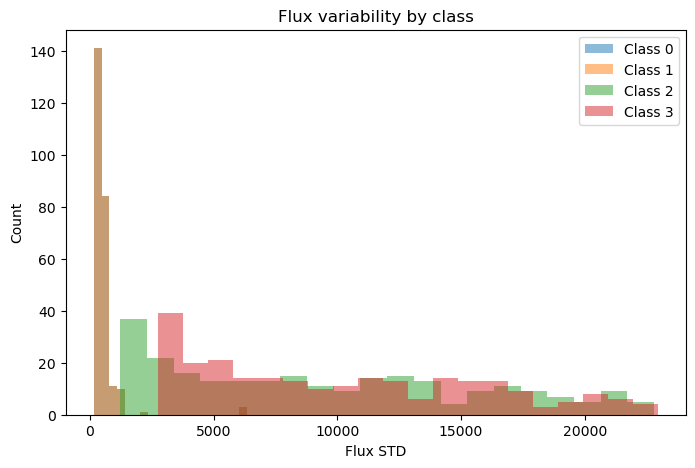

In [25]:
plt.figure(figsize=(8,5))

for cls in [0,1,2,3]:

    subset = metadata[metadata["class"] == cls]

    plt.hist(subset["flux_std"],
             bins=20,
             alpha=0.5,
             label=f"Class {cls}")

plt.legend()
plt.xlabel("Flux STD")
plt.ylabel("Count")
plt.title("Flux variability by class")

plt.show()

# Classical Transit Detection Baseline

A baseline transit detection experiment was performed using the Transit Least Squares (TLS) algorithm.

The objective was to evaluate whether injected planetary transit signals can be recovered from simulated PLATO-like light curves under stellar variability conditions.

The analysis was tested on a Class 2 sample containing:
- planetary transit
- stellar activity
- instrumental noise

The TLS algorithm searched for periodic transit-like dips in the normalized light curve.

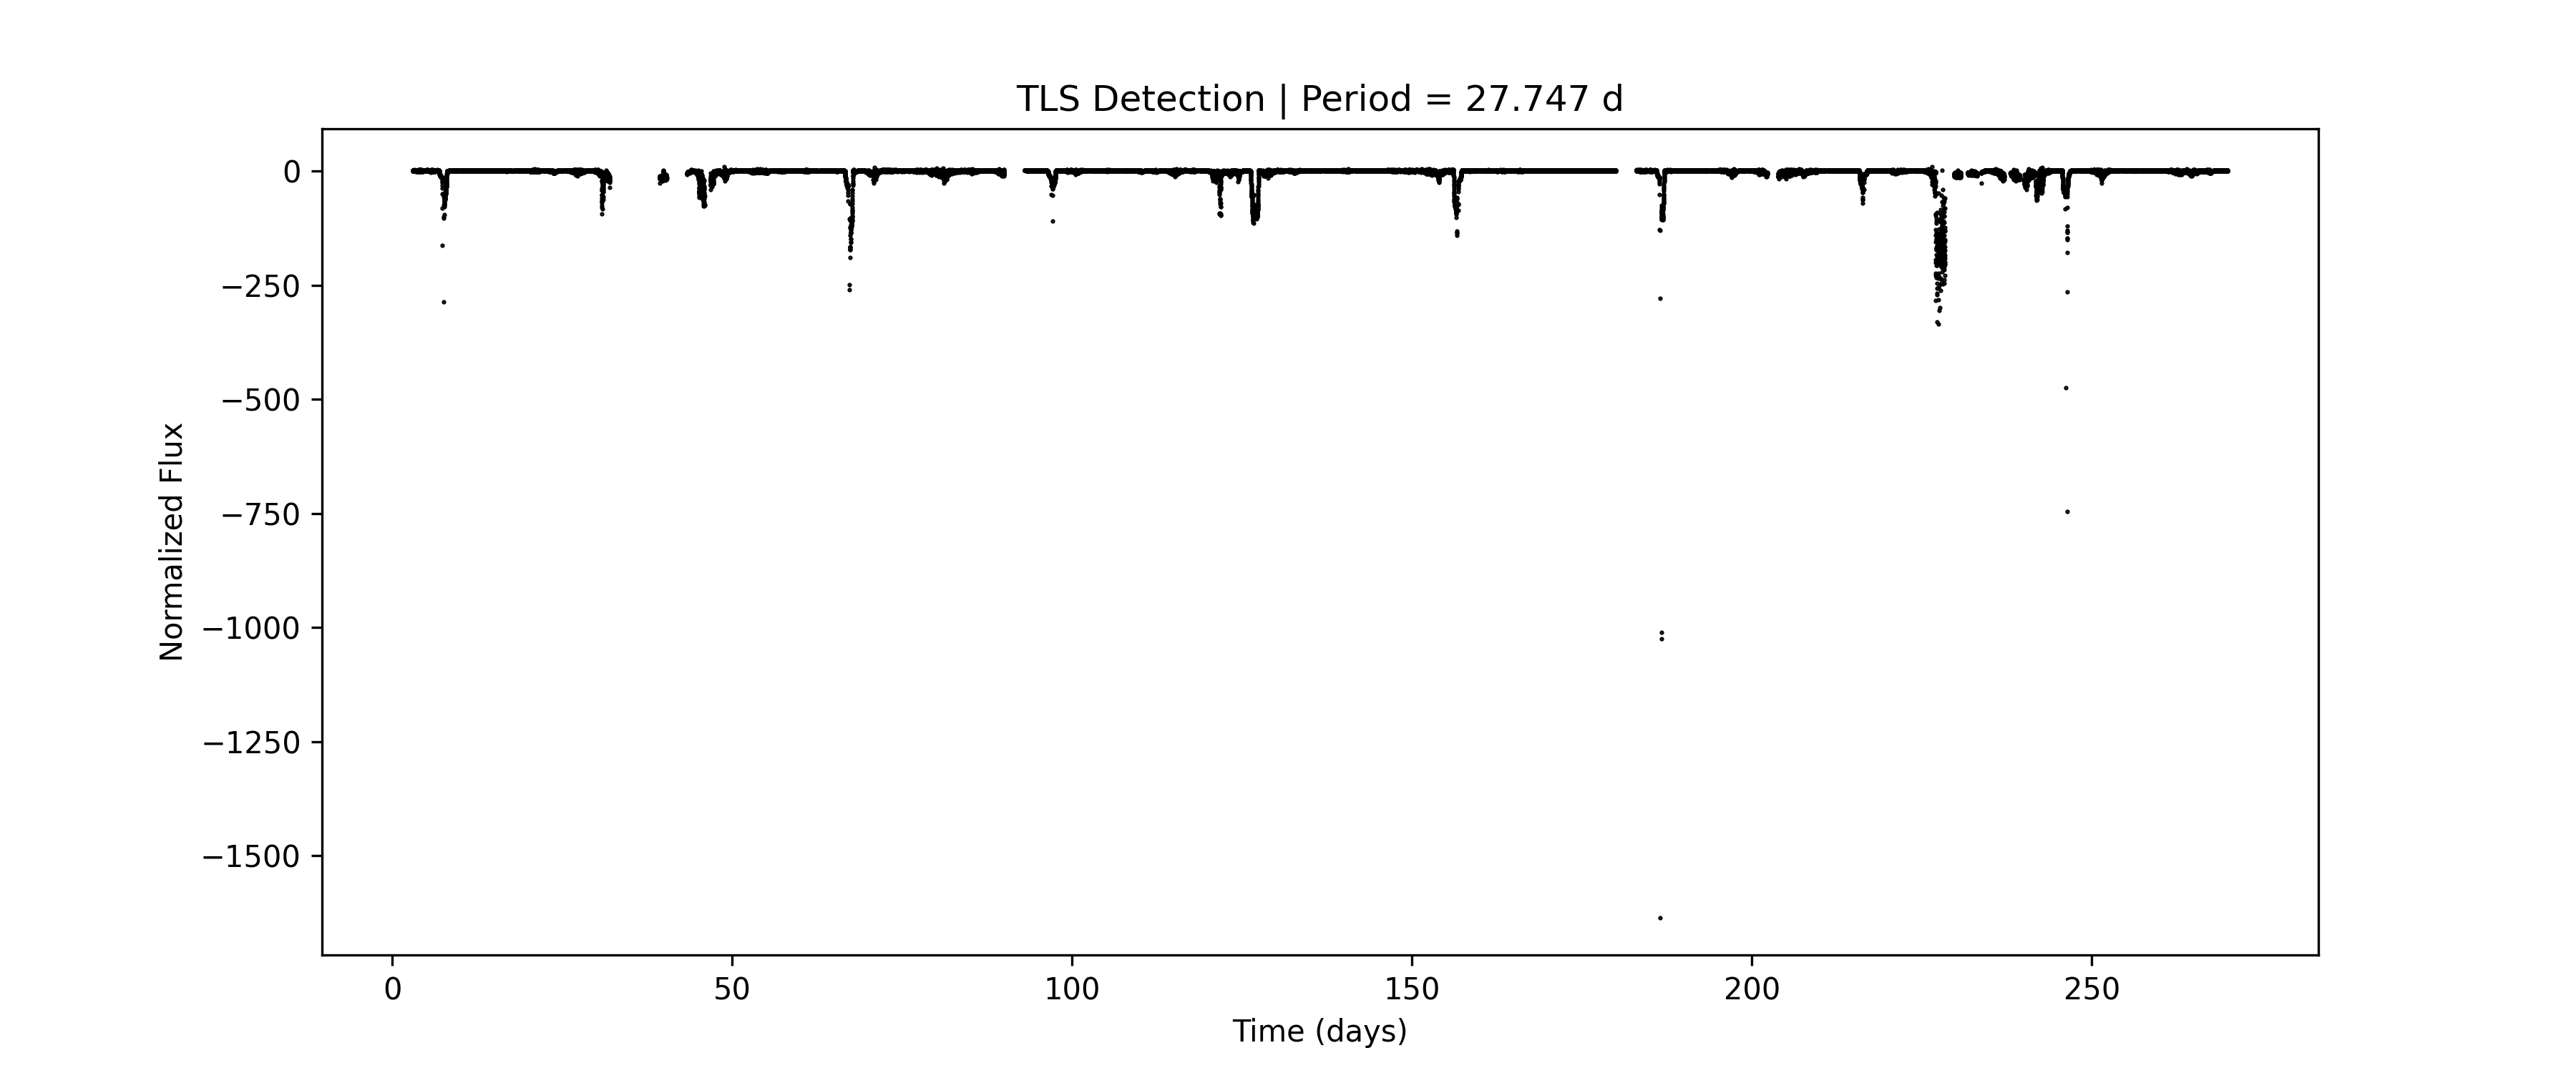

In [27]:
from IPython.display import Image

Image(filename="/home/israt/Downloads/psls/tls_detection.png")

In [28]:
best_period = 27.75
sde = 12.97

print("Detected period:", best_period, "days")
print("Signal Detection Efficiency:", sde)

Detected period: 27.75 days
Signal Detection Efficiency: 12.97
